In [7]:
from fastai.vision.all import *

path = untar_data(URLs.MNIST_SAMPLE)
three = (path/'train'/'3').ls().sorted()
seven = (path/'train'/'7').ls().sorted()
# path.ls()
# (path/'train').ls()



In [9]:
im3_sample = three[1]
im3 = Image.open(im3_sample)
im3

In [17]:
np.array(im3)[4:10,4:10]

array([[  0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,  29],
       [  0,   0,   0,  48, 166, 224],
       [  0,  93, 244, 249, 253, 187],
       [  0, 107, 253, 253, 230,  48],
       [  0,   3,  20,  20,  15,   0]], dtype=uint8)

In [18]:
t = tensor(im3)[4:10,4:10]

In [24]:
import pandas as pd

t = tensor(im3)
t = pd.DataFrame(t[4:22, 4:22])
t.style.set_properties(**{'font-size': '6pt'}).background_gradient('Greys')

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,29,150,195,254,255,254,176,193,150,96,0,0,0
2,0,0,0,48,166,224,253,253,234,196,253,253,253,253,233,0,0,0
3,0,93,244,249,253,187,46,10,8,4,10,194,253,253,233,0,0,0
4,0,107,253,253,230,48,0,0,0,0,0,192,253,253,156,0,0,0
5,0,3,20,20,15,0,0,0,0,0,43,224,253,245,74,0,0,0
6,0,0,0,0,0,0,0,0,0,0,249,253,245,126,0,0,0,0
7,0,0,0,0,0,0,0,14,101,223,253,248,124,0,0,0,0,0
8,0,0,0,0,0,11,166,239,253,253,253,187,30,0,0,0,0,0
9,0,0,0,0,0,16,248,250,253,253,253,253,232,213,111,2,0,0


In [25]:
three_tensors = [tensor(Image.open(i)) for i in three]
seven_tensors = [tensor(Image.open(i)) for i in seven]
len(three_tensors), len(seven_tensors)

(6131, 6265)

<Axes: >

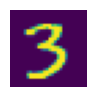

In [26]:
show_image(three_tensors[1])

In [27]:
stacked_trees = torch.stack(three_tensors).float()/255
stacked_sevens = torch.stack(seven_tensors).float()/255
stacked_trees.shape

torch.Size([6131, 28, 28])

<Axes: >

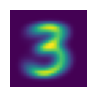

In [30]:
mean3 = stacked_trees.mean(0)
show_image(mean3)

<Axes: >

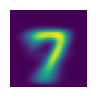

In [31]:
mean7 = stacked_sevens.mean(0)
show_image(mean7)

<Axes: >

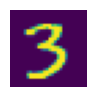

In [40]:
s_3 = stacked_trees[1]
s_7 = stacked_sevens[1]
show_image(s_3)

In [37]:
# MAE
mae = (s_3 - mean3).abs().mean()

# RMSE
rmse = ((s_3 - mean3)**2).mean().sqrt()
mae, rmse

(tensor(0.1114), tensor(0.2021))

In [42]:
# MAE
mae = (s_7 - mean7).abs().mean()

# RMSE
rmse = ((s_7 - mean7)**2).mean().sqrt()
mae, rmse

(tensor(0.1304), tensor(0.2585))